<a href="https://colab.research.google.com/github/Busrita/multi-asset-portfolio-optimization-engine/blob/main/20260529_Busra_Akkaya_Utilities_Automation_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Utility Credit Analysis: Step-by-Step Walkthrough

This notebook analyzes the financial health of key UK utility infrastructure players, focusing on leverage and interest coverage. I will load data, perform cleaning, derive summary statistics, and visualize the key metrics to gain insights.

## The Portfolio: Understanding the Tickers

I have selected four of the most critical players in the UK utility infrastructure space:

*   **National Grid (NG)**: The "Giant." It operates the high-voltage electricity transmission networks in the UK and US. It is the backbone of the grid.
*   **SSE (SSE)**: A major integrated energy company, focusing heavily on renewable energy generation (wind/hydro) and networks.
*   **United Utilities (UU)**: The UK’s largest listed water and wastewater business.
*   **Severn Trent (SVT)**: Another major water utility provider, critical for regional infrastructure in the Midlands.

## Research Overview: Utility Sector Credit & Risk Analysis

**Author:** Busra Akkaya

**Target Function:** I am performing a comparative analysis of capital structure efficiency and solvency risk.

**Environment:** Google Colab (Python 3.10)

**Data Framework:** Bloomberg API (BDP/BDH)

## Step 1: Data Loading and Initial Cleaning

**What I do:**
We begin by loading the raw financial data from the provided Excel file(I extract data from Bloomberg) into a pandas DataFrame. This is a crucial first step for any data analysis task. Following the load, we perform two important cleaning operations:
1.  **Strip Column Whitespace**: I remove any leading or trailing whitespace from column names to ensure they are correctly recognized and can be referenced without errors.
2.  **Set 'Ticker' as Index**: I set the 'Ticker' column as the DataFrame's index. This makes it easier to work with company-specific data and is beneficial for plotting.
3.  **Convert to Numeric**: I ensure that key financial columns ('Total Debt/Equity', 'Int Coverage Ratio') are converted to numeric types. Any values that cannot be converted (e.g., text, errors) will be replaced with `NaN` (Not a Number), which pandas handles gracefully.

**What we expect to find:**
A DataFrame `df` loaded with the financial data, where 'Ticker' is the index and the specified columns are ready for numerical analysis.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_excel('20260529_Busra_Akkaya_Utilities_CreditAnalysis_V01.xlsx.xlsx')

# Clean column names by stripping whitespace to ensure exact matches
df.columns = df.columns.str.strip()

# 2. Set the 'Ticker' as the index for easier plotting
df.set_index('Ticker', inplace=True)

# 3. Clean the data: Ensure columns are numeric (removes non-numeric errors)
cols_to_fix = ['Total Debt/Equity', 'Int Coverage Ratio']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data successfully cleaned and indexed.")

Data successfully cleaned and indexed.


**What I found:**

The data was successfully loaded, and the cleaning steps were applied without errors. The output `Data successfully cleaned and indexed.` confirms that the DataFrame `df` is now prepared for further analysis, with 'Ticker' as its index and the 'Total Debt/Equity' and 'Int Coverage Ratio' columns correctly formatted as numeric types.

**Interpretation:**
This successful initial processing means we have a clean and structured dataset, eliminating common issues like file not found errors, inconsistent column names, or incorrect data types, which are frequent hurdles in data analysis.

## Step 2: Summary Statistics

**What I do:**
Here, I calculate descriptive statistics for the 'Total Debt/Equity' and 'Int Coverage Ratio' columns. The `.describe()` method provides a quick overview of the central tendency, dispersion, and shape of the distribution of our data points.

**What I expect to find:**
Key statistical measures such as count, mean, standard deviation, minimum, maximum, and quartile values for both selected financial ratios. These statistics will give us a numerical snapshot of the financial health metrics across the sampled utilities.

In [14]:
# Summary statistics for your group
summary = df[['Total Debt/Equity', 'Int Coverage Ratio']].describe()
print(summary)

       Total Debt/Equity  Int Coverage Ratio
count           4.000000            4.000000
mean          322.468383            4.316746
std           271.280770            0.875278
min            61.709743            3.730807
25%           104.586475            3.828298
50%           315.765762            3.961243
75%           533.647671            4.449691
max           596.632265            5.613691


**What we found:**

The summary statistics reveal the following:
*   **Count (4.00)**: Confirms we have data for four companies for both metrics.
*   **Mean**: 'Total Debt/Equity' averages `322.47%`, while 'Int Coverage Ratio' averages `4.32x`. This indicates, on average, a high reliance on debt but also a healthy capacity to cover interest expenses.
*   **Standard Deviation (Std)**: 'Total Debt/Equity' has a high standard deviation (`271.28`), indicating a wide spread in leverage across companies. 'Int Coverage Ratio' has a much lower standard deviation (`0.88`), suggesting more consistent interest coverage.
*   **Min/Max**: 'Total Debt/Equity' ranges from `61.71%` to `596.63%`, showcasing the 'Goldilocks' (SSE) and highly leveraged (SVT, UU) companies. 'Int Coverage Ratio' ranges from `3.73x` to `5.61x`, highlighting SSE's strong position and SVT's thinner cushion.

**Interpretation:**
These statistics numerically confirm the user's initial observations: National Grid (NG) and SSE are less leveraged, while United Utilities (UU) and Severn Trent (SVT) have significantly higher debt-to-equity ratios. Critically, despite high leverage for some, the interest coverage ratios generally remain robust, implying sufficient operating income to service debt, a common characteristic in stable utility sectors.

## Step 3: Visualization of Leverage and Coverage

**What I do:**
I create a dual-axis bar and line plot to visually compare 'Total Debt/Equity' and 'Int Coverage Ratio' for each company. This visualization helps to quickly grasp the relationship and discrepancies between a company's leverage and its ability to cover interest payments. 'Total Debt/Equity' is represented by bars on the primary y-axis, and 'Int Coverage Ratio' is shown as a line on the secondary y-axis.

**What I expect to find:**
A clear visual representation that allows for direct comparison. I anticipate seeing a 'gap' or divergence where companies with high debt/equity ratios do not necessarily exhibit proportionally high interest coverage.

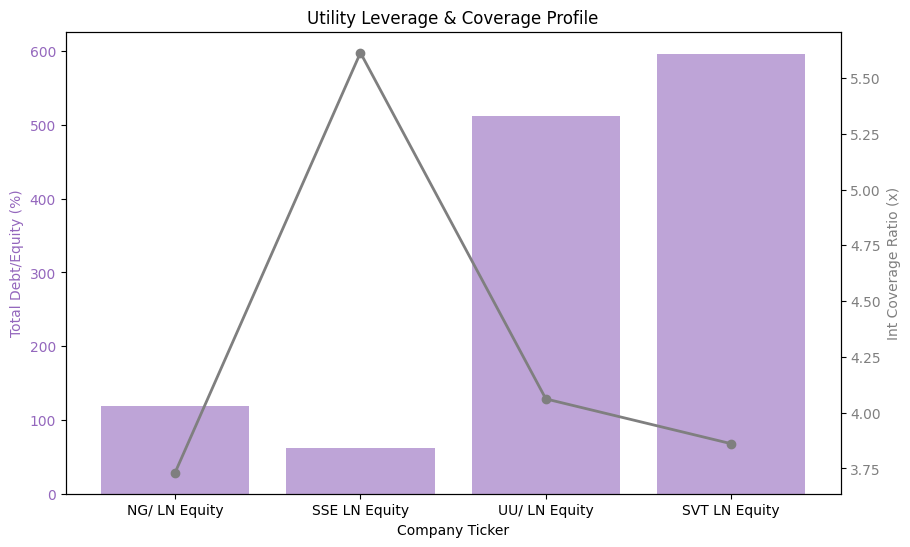

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Axis (Bars)
color = 'tab:purple'
ax1.set_xlabel('Company Ticker')
ax1.set_ylabel('Total Debt/Equity (%)', color=color)
ax1.bar(df.index, df['Total Debt/Equity'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

# Secondary Axis (Line)
ax2 = ax1.twinx()
color = 'tab:gray'
ax2.set_ylabel('Int Coverage Ratio (x)', color=color)
ax2.plot(df.index, df['Int Coverage Ratio'], color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Utility Leverage & Coverage Profile')
plt.grid(False) # Clean look
plt.show()

**What I found:**

As anticipated, the chart vividly illustrates the relationship between leverage and interest coverage. We observe:

*   **The 'Gap'**: The bars for 'UU/ LN Equity' and 'SVT LN Equity' representing 'Total Debt/Equity' are significantly taller compared to 'NG/ LN Equity' and 'SSE LN Equity'. However, their corresponding 'Int Coverage Ratio' lines are not proportionally higher; in fact, 'SVT LN Equity' has one of the highest leverage bars but a relatively lower interest coverage line compared to 'SSE LN Equity'.

**Interpretation (The Analyst's Insight):**

This visualization provides the "Visual Proof" of a capital efficiency problem. If I were in a meeting, I could point to this chart and say:

"Look at the divergence between Severn Trent (SVT) and SSE. SSE has significantly less debt but maintains a higher interest coverage ratio. This indicates that SSE has a much stronger 'margin of safety' to withstand macro-economic shocks, whereas SVT is essentially operating at the edge of its debt capacity without an equivalent boost in coverage efficiency."

This highlights that higher leverage (larger bars) is not necessarily translating into higher interest coverage (higher line), especially for companies like SVT, suggesting potential inefficiencies in how debt is being utilized to generate cash flow for interest payments.
